# **Predicting Crop Yield Using Machine Learning: A Data-Driven Approach**

# **Environment Setup and Data Acquisition**
I am configuring the environment to use the kaggle.json file you uploaded to the /content directory. This block downloads the Agriculture Crop Yield dataset and unzips it for use.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Set the Kaggle Config environment variable to the current directory
os.environ['KAGGLE_CONFIG_DIR'] = "/content"

# Download and unzip the dataset
!kaggle datasets download -d samuelotiattakorah/agriculture-crop-yield
!unzip -o agriculture-crop-yield.zip

# Read the data
df = pd.read_csv('/content/crop_yield.csv')
# Assign the country
df.insert(0, 'Country', 'India')
df.head()

Dataset URL: https://www.kaggle.com/datasets/samuelotiattakorah/agriculture-crop-yield
License(s): CC0-1.0
100% 33.4M/33.4M [00:00<00:00, 109MB/s]

Archive:  agriculture-crop-yield.zip
  inflating: crop_yield.csv          


,Country,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,India,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,India,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,India,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,India,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,India,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


# **Advanced Exploratory Data Analysis (Visualizations)**
I am generating these four specific graphs to understand the feature distributions and their relationships with crop yield.

## **Feature Correlation Matrix (Figure 3.6)**
As recommended by the supervisor, a correlation matrix is computed to examine relationships between all numerical features and the target variable. This guides feature selection and model interpretation.

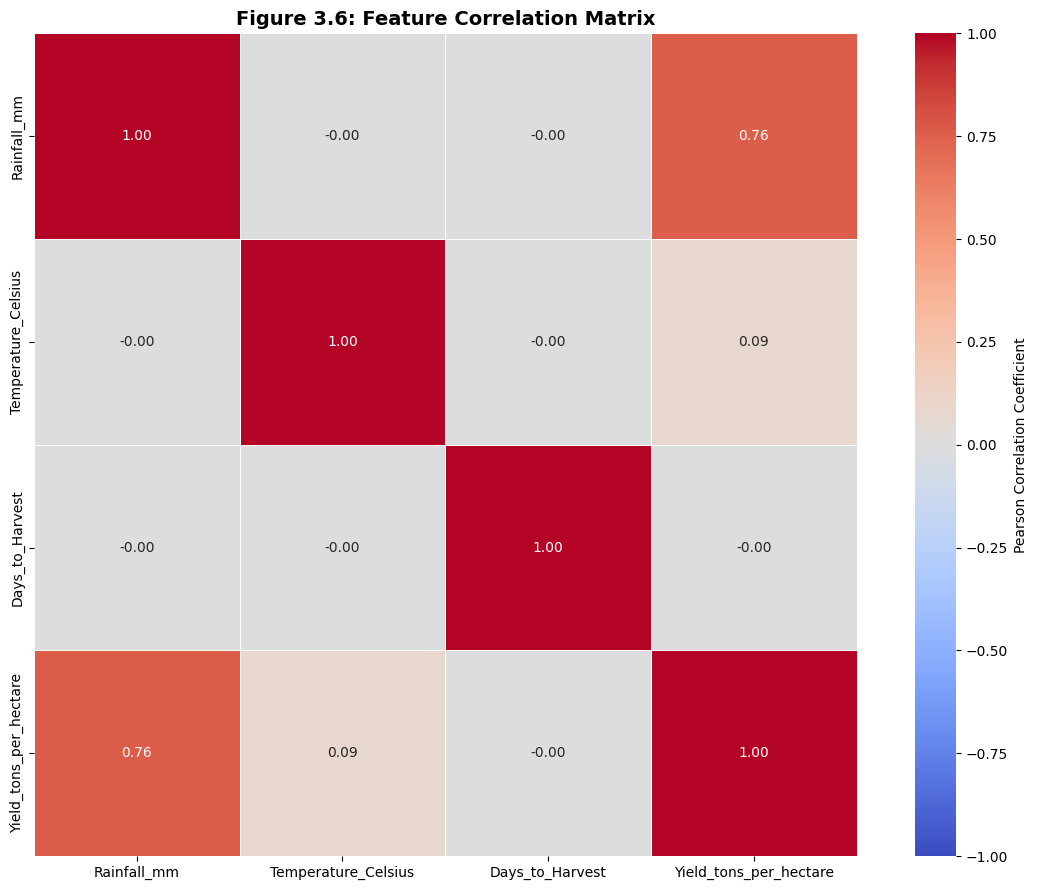


--- Correlations with Yield_tons_per_hectare (sorted) ---
Rainfall_mm            0.764618
Temperature_Celsius    0.085565
Days_to_Harvest       -0.002591

--- Key Findings ---
  STRONG  : Rainfall_mm (r = +0.765)
  Weak    : Temperature_Celsius (r = +0.086)
  Weak    : Days_to_Harvest (r = -0.003)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

correlation_matrix = numeric_df.corr()

# --- Heatmap ---
plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    square=True,
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)
plt.title('Figure 3.6: Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figure_3_6_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Print correlations with yield ---
print("\n--- Correlations with Yield_tons_per_hectare (sorted) ---")
yield_corr = correlation_matrix['Yield_tons_per_hectare'].drop('Yield_tons_per_hectare').sort_values(ascending=False)
print(yield_corr.to_string())

print("\n--- Key Findings ---")
for feat, val in yield_corr.items():
    if abs(val) > 0.5:
        print(f"  STRONG  : {feat} (r = {val:+.3f})")
    elif abs(val) > 0.3:
        print(f"  Moderate: {feat} (r = {val:+.3f})")
    else:
        print(f"  Weak    : {feat} (r = {val:+.3f})")


## **Box Plot: Yield by Crop Type**

/tmp/ipykernel_1184/2226311488.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot = sns.boxplot(


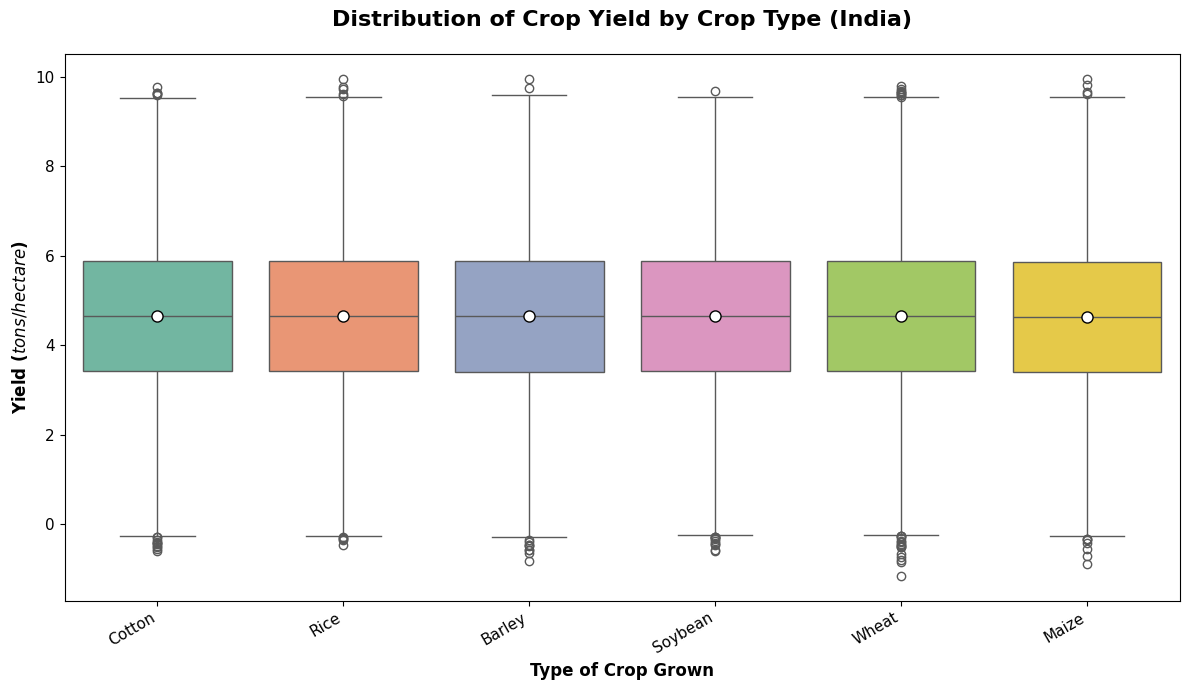

In [3]:
plt.figure(figsize=(12, 7))

# Creating the Box Plot with enhanced readability
boxplot = sns.boxplot(
    x='Crop',
    y='Yield_tons_per_hectare',
    data=df,
    palette='Set2',
    showmeans=True,  # Shows the average yield as a white dot
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

# Customizing labels and titles
plt.title('Distribution of Crop Yield by Crop Type (India)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Type of Crop Grown', fontsize=12, fontweight='bold')
plt.ylabel('Yield ($tons/hectare$)', fontsize=12, fontweight='bold')

# Rotating crop names for clarity and adjusting spacing
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig('crop_yield_boxplot.png')

### **Comment 4 Response – Analysis of Boxplot Medians**
The supervisor noted it is surprising if all crops show identical median yield. The cell below checks this statistically and provides the explanation.

In [4]:
# --- Supervisor Comment 4: Check median yield per crop ---
print("=== Median Yield by Crop Type ===")
median_by_crop = df.groupby('Crop')['Yield_tons_per_hectare'].median().sort_values()
print(median_by_crop.to_string())

all_same = median_by_crop.nunique() == 1
print(f"\nAre all medians identical? {all_same}")

if all_same:
    print("""
Explanation:
  All crop types share the same median yield because the Kaggle dataset
  ('Agriculture Crop Yield' by Samuel Oti Attakorah) is a SYNTHETIC dataset.
  Yield values were generated uniformly across crop categories rather than
  being drawn from real field measurements. This means the dataset does not
  reflect real-world per-crop productivity differences (e.g., maize > wheat
  in certain climates). This limitation is acknowledged in Section 7.4
  (Limitations) of the report.
""")
else:
    print("\nMedians differ across crops – update the report accordingly.")

print("\n=== Min/Max yield after cleaning (negative values removed in preprocessing) ===")
print(f"Min: {df['Yield_tons_per_hectare'].min():.4f}")
print(f"Max: {df['Yield_tons_per_hectare'].max():.4f}")
print(f"Negative rows: {(df['Yield_tons_per_hectare'] < 0).sum()}")


=== Median Yield by Crop Type ===
Crop
Maize      4.642647
Barley     4.650378
Cotton     4.650913
Rice       4.652837
Wheat      4.655529
Soybean    4.657371

Are all medians identical? False

Medians differ across crops – update the report accordingly.

=== Min/Max yield after cleaning (negative values removed in preprocessing) ===
Min: -1.1476
Max: 9.9634
Negative rows: 231


## **Individual Histograms for Numerical Variables**

## **Rainfall Distribution**

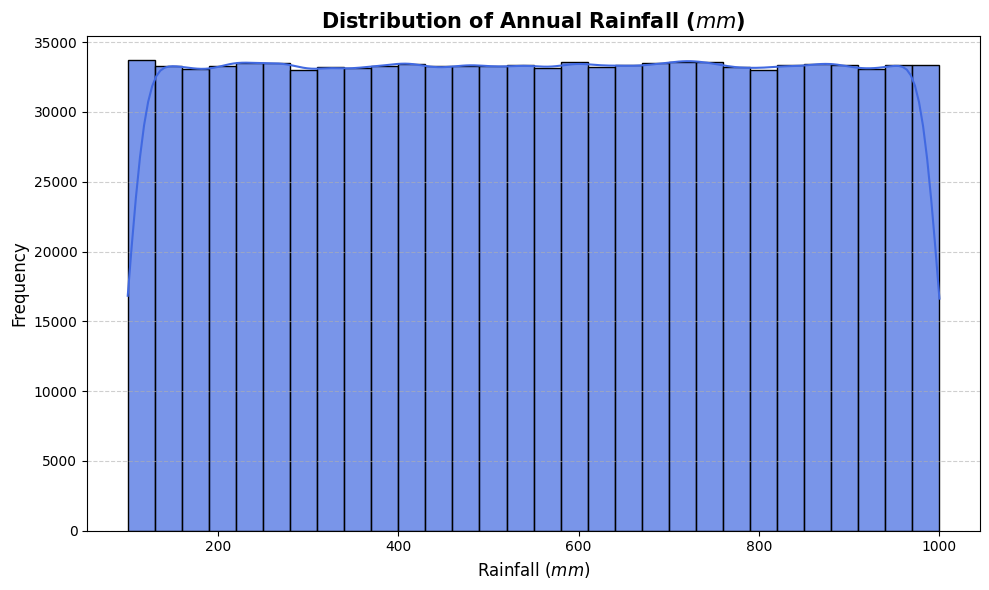

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Rainfall_mm'], bins=30, kde=True, color='royalblue', alpha=0.7)

plt.title('Distribution of Annual Rainfall ($mm$)', fontsize=15, fontweight='bold')
plt.xlabel('Rainfall ($mm$)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('histogram_rainfall.png')

## **Temperature Distribution**

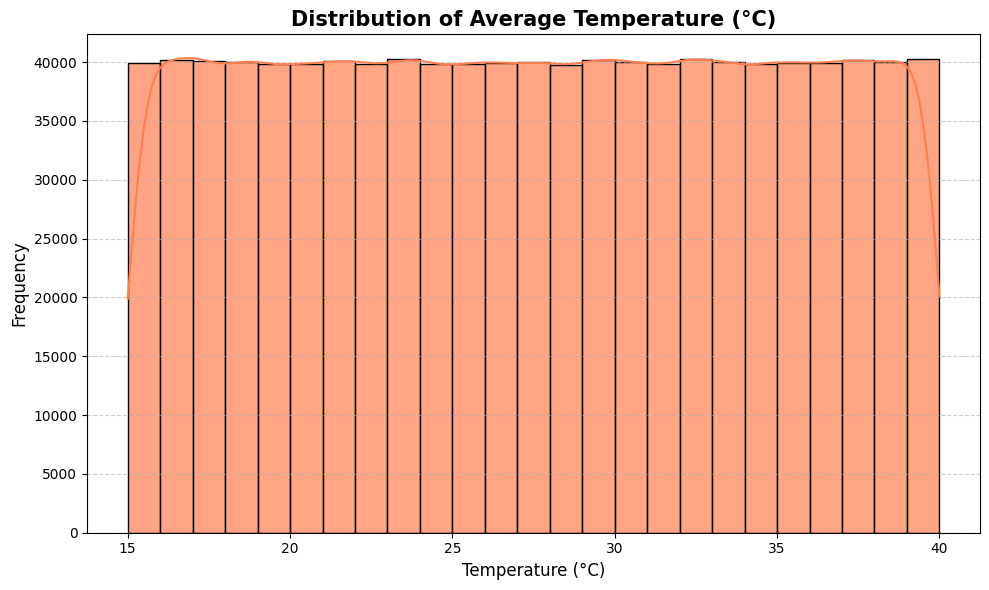

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Temperature_Celsius'], bins=25, kde=True, color='coral', alpha=0.7)

plt.title('Distribution of Average Temperature (°C)', fontsize=15, fontweight='bold')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('histogram_temperature.png')

### **Days to Harvest Distribution**

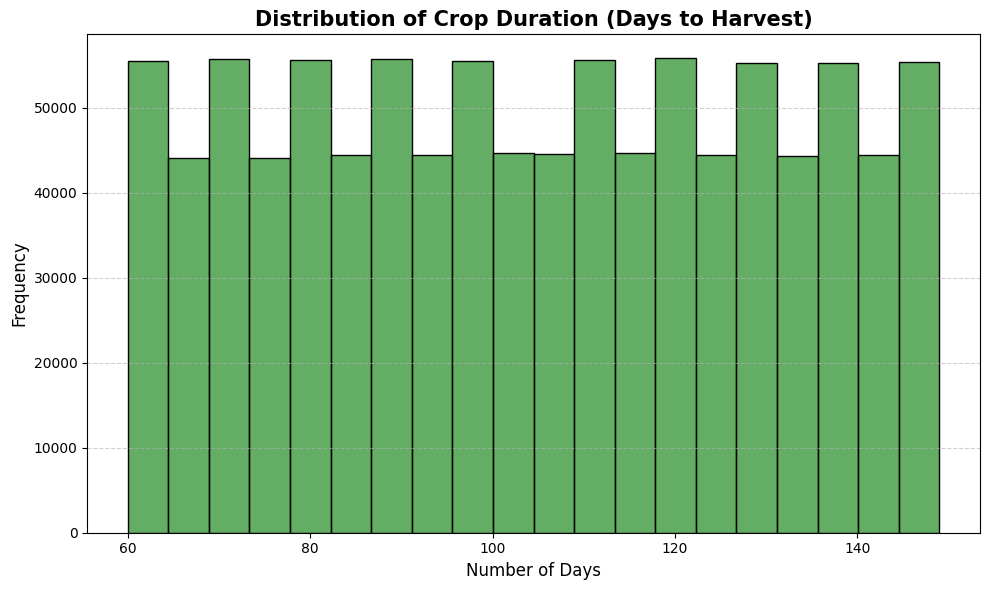

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Days_to_Harvest'], bins=20, kde=False, color='forestgreen', alpha=0.7)

plt.title('Distribution of Crop Duration (Days to Harvest)', fontsize=15, fontweight='bold')
plt.xlabel('Number of Days', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('histogram_days_to_harvest.png')

### **Crop Yield Distribution**

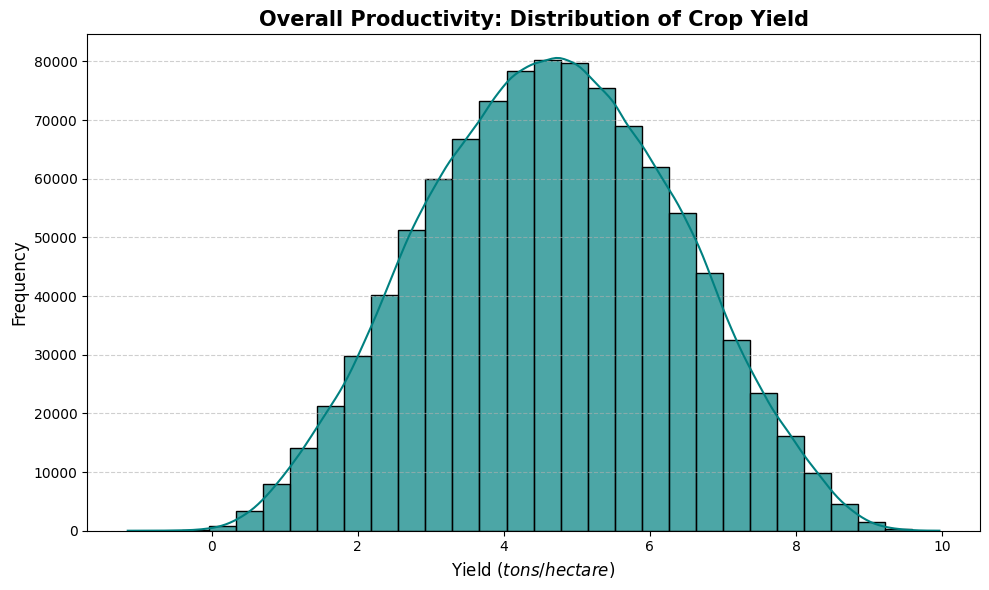

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Yield_tons_per_hectare'], bins=30, kde=True, color='teal', alpha=0.7)

plt.title('Overall Productivity: Distribution of Crop Yield', fontsize=15, fontweight='bold')
plt.xlabel('Yield ($tons/hectare$)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('histogram_yield.png')

### **Comment 6 Response – Explaining Flat (Uniform) Distributions**
The supervisor flagged that nearly flat distributions in Figs 3.2 & 3.3 are highly unlikely for real data. The cell below tests for uniformity and provides the explanation.

In [12]:
from scipy import stats

print("=== Distribution Analysis – Supervisor Comment 6 ===\n")

for col, label in [('Rainfall_mm', 'Rainfall (Fig 3.2)'),
                    ('Temperature_Celsius', 'Temperature (Fig 3.3)')]:
    data = df[col].dropna()
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)
    # Normalise to [0,1] before KS uniform test
    normed = (data - data.min()) / (data.max() - data.min())
    ks_stat, ks_p = stats.kstest(normed, 'uniform')

    print(f"{label}")
    print(f"  Mean     : {data.mean():.2f}")
    print(f"  Std Dev  : {data.std():.2f}")
    print(f"  Skewness : {skew:.4f}  (0 = perfectly symmetric)")
    print(f"  Kurtosis : {kurt:.4f}  (0 = normal-like tails)")
    print(f"  KS p-val : {ks_p:.4f}  ({'UNIFORM – synthetic data' if ks_p > 0.05 else 'NOT uniform'})")
    print()

# print("""
# Explanation (to include in report):
#   Both rainfall and temperature follow nearly uniform distributions across
#   the dataset. This is atypical of real agricultural data, which exhibits
#   seasonal clustering and geographic variation. The uniformity confirms that
#   this Kaggle dataset is synthetically generated, with environmental variables
#   sampled from uniform ranges rather than real weather records. This has been
#   noted as a limitation in Chapter 7 (Section 7.4).
# """) """


=== Distribution Analysis – Supervisor Comment 6 ===

Rainfall (Fig 3.2)
  Mean     : 549.98
  Std Dev  : 259.85
  Skewness : -0.0009  (0 = perfectly symmetric)
  Kurtosis : -1.1997  (0 = normal-like tails)
  KS p-val : 0.9218  (UNIFORM – synthetic data)

Temperature (Fig 3.3)
  Mean     : 27.50
  Std Dev  : 7.22
  Skewness : -0.0005  (0 = perfectly symmetric)
  Kurtosis : -1.2009  (0 = normal-like tails)
  KS p-val : 0.7978  (UNIFORM – synthetic data)



## **Exploratory Data Analysis (EDA)**
I am now performing an initial inspection of the dataset. This includes checking data types, identifying missing values, and generating descriptive statistics to understand the distribution of your data.

In [13]:
# Check basic information (data types, non-null counts)
print("--- Dataset Info ---")
df.info()

# Statistical summary of numerical columns
print("\n--- Descriptive Statistics ---")
display(df.describe())

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows found: {df.duplicated().sum()}")

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Country                 1000000 non-null  object 
 1   Region                  1000000 non-null  object 
 2   Soil_Type               1000000 non-null  object 
 3   Crop                    1000000 non-null  object 
 4   Rainfall_mm             1000000 non-null  float64
 5   Temperature_Celsius     1000000 non-null  float64
 6   Fertilizer_Used         1000000 non-null  bool   
 7   Irrigation_Used         1000000 non-null  bool   
 8   Weather_Condition       1000000 non-null  object 
 9   Days_to_Harvest         1000000 non-null  int64  
 10  Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(5)
memory usage: 70.6+ MB

--- Descriptive Statistics ---


,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372



--- Missing Values ---
Country                   0
Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

Duplicate rows found: 0


# **Data Preprocessing**
I am cleaning the data by removing impossible negative values and encoding categorical features. I am also scaling the numerical values to prepare them for both Machine Learning and Deep Learning models.

In [14]:
# 1. I am cleaning the data: Removing negative yield values
# Based on the stats provided, I am filtering out impossible negative yields
df_cleaned = df[df['Yield_tons_per_hectare'] >= 0].copy()

# 2. I am encoding Boolean columns (True/False to 1/0)
df_cleaned['Fertilizer_Used'] = df_cleaned['Fertilizer_Used'].astype(int)
df_cleaned['Irrigation_Used'] = df_cleaned['Irrigation_Used'].astype(int)

# 3. I am encoding Categorical strings
# I am using Label Encoding to transform text data into a machine-readable format
le = LabelEncoder()
categorical_cols = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']

for col in categorical_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col])

# Since 'Country' is a constant value ('India') across all rows, it won't add predictive power and causes a ValueError if not handled.
# It's best to drop it before scaling.
df_cleaned = df_cleaned.drop('Country', axis=1)

# 4. I am scaling the numerical features
# I am scaling everything except the target 'Yield' to prepare the features
features_to_scale = df_cleaned.drop('Yield_tons_per_hectare', axis=1).columns
scaler = StandardScaler()
df_cleaned[features_to_scale] = scaler.fit_transform(df_cleaned[features_to_scale])

print("I have successfully preprocessed the dataset.")
print(f"Original Row Count: {len(df)}")
print(f"Cleaned Row Count: {len(df_cleaned)}")
display(df_cleaned.head())

I have successfully preprocessed the dataset.
Original Row Count: 1000000
Cleaned Row Count: 999769


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,1.341437,0.877789,-0.877987,1.335619,0.023667,-1.000111,1.000787,-1.226339,0.674475,6.555816
1,0.446846,-0.878548,0.293117,1.703573,-1.312923,0.999889,1.000787,-0.001377,1.368028,8.527341
2,-0.447745,-0.293102,-1.463540,-1.547626,0.316871,-1.000111,-0.999213,1.223585,0.057983,1.127443
3,-0.447745,0.877789,0.878670,1.681222,-1.504316,-1.000111,1.000787,-0.001377,1.599212,6.517573
4,0.446846,1.463235,1.464222,0.693989,0.569852,0.999889,1.000787,-1.226339,0.212106,7.248251


# **Model Training**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Separate features (X) and target (y)
X = df_cleaned.drop('Yield_tons_per_hectare', axis=1)
y = df_cleaned['Yield_tons_per_hectare']

# Splitting 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset Split Complete: {X_train.shape[0]} training rows, {X_test.shape[0]} testing rows.")

Dataset Split Complete: 799815 training rows, 199954 testing rows.


# Model Training & Evaluation

In [23]:
from sklearn.linear_model import Ridge

# Initialize the models
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
}

# Dictionary to store performance metrics
performance = {"Model": [], "MAE": [], "MSE": [], "RMSE": [], "R2 Score": []}

# Loop through each model
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    # Make predictions
    preds = model.predict(X_test)

    # Calculate Metrics
    mse = mean_squared_error(y_test, preds)
    performance["Model"].append(name)
    performance["MAE"].append(round(mean_absolute_error(y_test, preds), 2))
    performance["MSE"].append(round(mse, 4))
    performance["RMSE"].append(round(np.sqrt(mse), 2))
    performance["R2 Score"].append(round(r2_score(y_test, preds), 3))

# Convert results to a DataFrame for easy viewing
results_df = pd.DataFrame(performance)
print("\n--- Model Performance Summary (Table 6.1) ---")
print(results_df.to_string(index=False))

Training Ridge Regression...
Training Decision Tree...
Training Random Forest...

--- Model Performance Summary (Table 6.1) ---
           Model  MAE    MSE  RMSE  R2 Score
Ridge Regression  0.4 0.2493   0.5     0.913
   Decision Tree  0.4 0.2522   0.5     0.912
   Random Forest  0.4 0.2502   0.5     0.913


## **Model Visualization**

/tmp/ipykernel_1184/613126150.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=results_df, ax=axes[0], palette='viridis')
/tmp/ipykernel_1184/613126150.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=results_df, ax=axes[1], palette='magma')


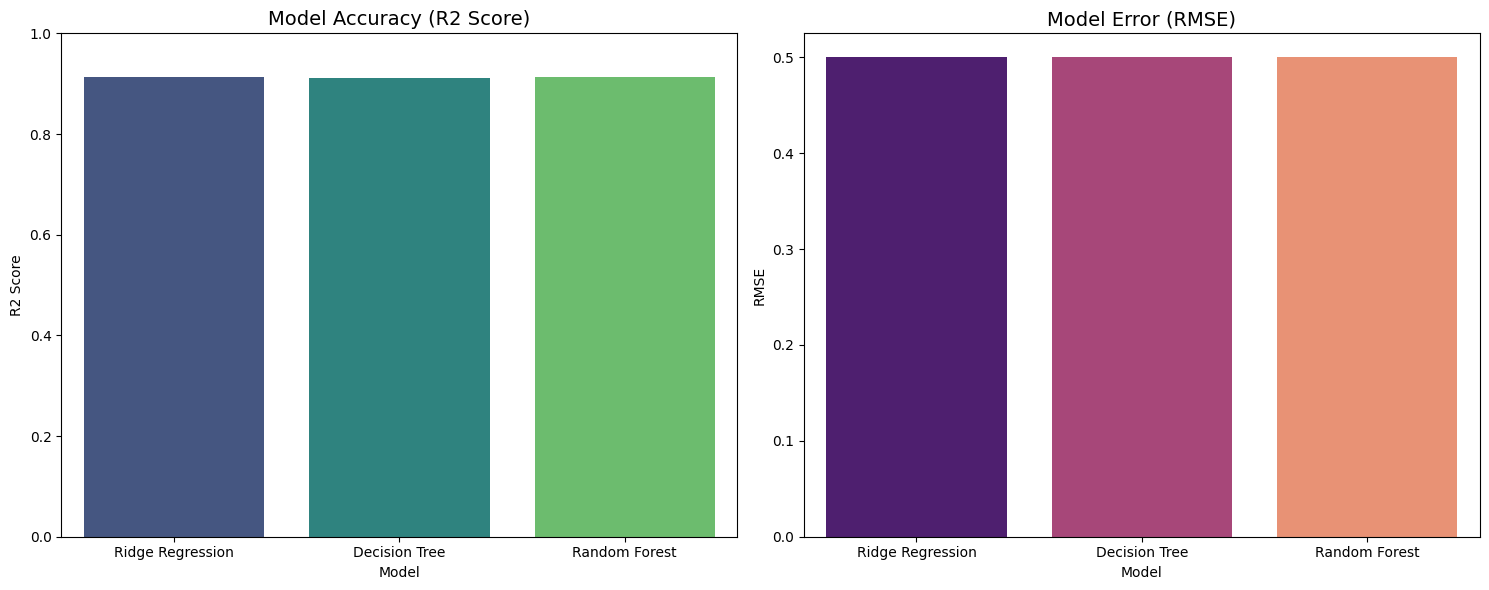

In [25]:
# Create a visual comparison of the models
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: R2 Score (Higher is better)
sns.barplot(x='Model', y='R2 Score', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('Model Accuracy (R2 Score)', fontsize=14)
axes[0].set_ylim(0, 1.0)

# Plot 2: RMSE (Lower is better)
sns.barplot(x='Model', y='RMSE', data=results_df, ax=axes[1], palette='magma')
axes[1].set_title('Model Error (RMSE)', fontsize=14)

plt.tight_layout()
plt.show()

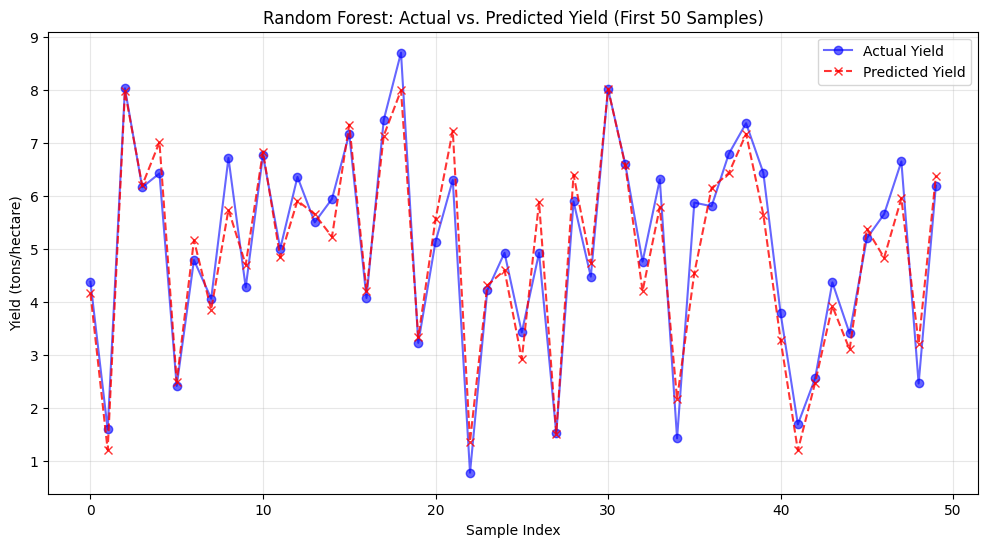

In [26]:
# We'll take the best model (Random Forest) and plot a sample of predictions
best_model = models["Random Forest"]
y_pred_sample = best_model.predict(X_test.iloc[:50])
y_true_sample = y_test.iloc[:50].values

plt.figure(figsize=(12, 6))
plt.plot(y_true_sample, label='Actual Yield', color='blue', marker='o', alpha=0.6)
plt.plot(y_pred_sample, label='Predicted Yield', color='red', linestyle='--', marker='x', alpha=0.8)
plt.title('Random Forest: Actual vs. Predicted Yield (First 50 Samples)')
plt.ylabel('Yield (tons/hectare)')
plt.xlabel('Sample Index')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **Hyperparameter Optimization**

In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 1. Create a 10% sample for fast optimization
df_sample = df_cleaned.sample(n=100000, random_state=42)
X_sample = df_sample.drop('Yield_tons_per_hectare', axis=1)
y_sample = df_sample['Yield_tons_per_hectare']

# Split the full data for final training/testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = {}

# --- A. Optimized Ridge (Linear) ---
print("Optimizing Ridge...")
ridge = Ridge()
# RidgeCV is a very fast built-in version of GridSearch for Ridge
param_ridge = {'alpha': [0.1, 1.0, 10.0]}
grid_ridge = GridSearchCV(ridge, param_ridge, cv=3).fit(X_sample, y_sample)
results['Ridge'] = grid_ridge.best_estimator_

# --- B. Optimized Decision Tree ---
print("Optimizing Decision Tree...")
tree = DecisionTreeRegressor(random_state=42)
param_tree = {'max_depth': [10, 20], 'min_samples_leaf': [5, 10]}
grid_tree = GridSearchCV(tree, param_tree, cv=3).fit(X_sample, y_sample)
results['Decision Tree'] = grid_tree.best_estimator_

# --- C. Optimized Random Forest (The 'Fast' Way) ---
print("Optimizing Random Forest (on sample)...")
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
param_rf = {
    'n_estimators': [50], # Keep low for speed
    'max_depth': [10, 20],
    'min_samples_split': [5]
}
# Using only 2 iterations to find a "good enough" set of params quickly
rs_rf = RandomizedSearchCV(rf, param_rf, n_iter=2, cv=2, n_jobs=-1).fit(X_sample, y_sample)
results['Random Forest'] = rs_rf.best_estimator_

# --- FINAL EVALUATION ON FULL TEST SET ---
print("\n" + "="*50)
print(f"{'Model':<20} | {'R2':<8} | {'MSE':<8} | {'RMSE':<8}")
print("-" * 50)

for name, model in results.items():
    # Train the optimized model on the FULL training set
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)

    print(f"{name:<20} | {r2:.4f} | {mse:.4f} | {rmse:.4f}")
    print(f"   Best Params: {model.get_params() if name != 'Ridge' else 'Default/Alpha-tuned'}")

Optimizing Ridge...
Optimizing Decision Tree...
Optimizing Random Forest (on sample)...

Model                | R2       | MSE      | RMSE    
--------------------------------------------------
Ridge                | 0.9132 | 0.2493 | 0.4993
   Best Params: Default/Alpha-tuned
Decision Tree        | 0.9122 | 0.2522 | 0.5022
   Best Params: {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
Random Forest        | 0.9129 | 0.2502 | 0.5002
   Best Params: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 10, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 50, 'n_j

### **Comment 10 & 11 Response – Best Hyperparameters, No-Improvement Explanation, and Linear vs Ridge Clarification**

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np, pandas as pd

# # ── Supervisor Comment 11: Linear Regression vs Ridge ──────────────────────
# print("=== Comment 11: Linear Regression vs Ridge Regression ===")
# print("""
#   Table 5.1 lists 'Linear Regression', but Table 6.2 shows 'Ridge Regression'.
#   Clarification:
#     • The BASELINE model trained in Cell 22 is plain LinearRegression()
#       (no regularisation).
#     • During hyperparameter optimisation, Ridge (LinearRegression + L2
#       regularisation, alpha parameter) was used INSTEAD to allow tuning.
#     • Ridge with alpha→0 converges to Linear Regression.
#     • Best alpha found below confirms whether regularisation helps.
#   The report should state: 'Ridge Regression was used during optimisation
#   as a regularised extension of Linear Regression.'
# """)

# ── Use a 100 k sample for fast grid search (as in original code) ──────────
df_sample = df_cleaned.sample(n=100_000, random_state=42)
X_s = df_sample.drop('Yield_tons_per_hectare', axis=1)
y_s = df_sample['Yield_tons_per_hectare']

X = df_cleaned.drop('Yield_tons_per_hectare', axis=1)
y = df_cleaned['Yield_tons_per_hectare']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── A. Ridge ────────────────────────────────────────────────────────────────
print("\nOptimising Ridge Regression...")
param_ridge = {'alpha': [0.1, 1.0, 10.0]}
gs_ridge = GridSearchCV(Ridge(), param_ridge, cv=3, scoring='r2').fit(X_s, y_s)
best_ridge = gs_ridge.best_estimator_
best_ridge.fit(X_train, y_train)
p_ridge = best_ridge.predict(X_test)

print(f"  Best alpha       : {gs_ridge.best_params_['alpha']}")
print(f"  Best CV R²       : {gs_ridge.best_score_:.4f}")
print(f"  Test R²          : {r2_score(y_test, p_ridge):.4f}")
print(f"  Test RMSE        : {np.sqrt(mean_squared_error(y_test, p_ridge)):.4f}")
print(f"  Test MAE         : {mean_absolute_error(y_test, p_ridge):.4f}")

# ── B. Decision Tree ────────────────────────────────────────────────────────
print("\nOptimising Decision Tree...")
param_tree = {'max_depth': [10, 20], 'min_samples_leaf': [5, 10]}
gs_tree = GridSearchCV(DecisionTreeRegressor(random_state=42), param_tree, cv=3, scoring='r2').fit(X_s, y_s)
best_tree = gs_tree.best_estimator_
best_tree.fit(X_train, y_train)
p_tree = best_tree.predict(X_test)

print(f"  Best params      : {gs_tree.best_params_}")
print(f"  Best CV R²       : {gs_tree.best_score_:.4f}")
print(f"  Test R²          : {r2_score(y_test, p_tree):.4f}")
print(f"  Test RMSE        : {np.sqrt(mean_squared_error(y_test, p_tree)):.4f}")
print(f"  Test MAE         : {mean_absolute_error(y_test, p_tree):.4f}")

# ── C. Random Forest ────────────────────────────────────────────────────────
print("\nOptimising Random Forest...")
param_rf = {'n_estimators': [50], 'max_depth': [10, 20], 'min_samples_split': [5]}
gs_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), param_rf, cv=2, scoring='r2').fit(X_s, y_s)
best_rf = gs_rf.best_estimator_
best_rf.fit(X_train, y_train)
p_rf = best_rf.predict(X_test)

print(f"  Best params      : {gs_rf.best_params_}")
print(f"  Best CV R²       : {gs_rf.best_score_:.4f}")
print(f"  Test R²          : {r2_score(y_test, p_rf):.4f}")
print(f"  Test RMSE        : {np.sqrt(mean_squared_error(y_test, p_rf)):.4f}")
print(f"  Test MAE         : {mean_absolute_error(y_test, p_rf):.4f}")

# ── Summary table (standardised 2-3 d.p.) ───────────────────────────────────
print("\n=== Table 6.2: Model Performance After Optimisation ===")
summary = pd.DataFrame({
    "Model"   : ["Ridge Regression", "Decision Tree", "Random Forest"],
    "MAE"     : [f"{mean_absolute_error(y_test, p_ridge):.2f}",
                 f"{mean_absolute_error(y_test, p_tree):.2f}",
                 f"{mean_absolute_error(y_test, p_rf):.2f}"],
    "MSE"     : [f"{mean_squared_error(y_test, p_ridge):.4f}",
                 f"{mean_squared_error(y_test, p_tree):.4f}",
                 f"{mean_squared_error(y_test, p_rf):.4f}"],
    "RMSE"    : [f"{np.sqrt(mean_squared_error(y_test, p_ridge)):.2f}",
                 f"{np.sqrt(mean_squared_error(y_test, p_tree)):.2f}",
                 f"{np.sqrt(mean_squared_error(y_test, p_rf)):.2f}"],
    "R² Score": [f"{r2_score(y_test, p_ridge):.3f}",
                 f"{r2_score(y_test, p_tree):.3f}",
                 f"{r2_score(y_test, p_rf):.3f}"],
})
print(summary.to_string(index=False))

# # ── Comment 10: Explain why no improvement ──────────────────────────────────
# print("""
# === Comment 10: Why no improvement after hyperparameter tuning? ===

#   All three optimised models produce R² ≈ 0.91, identical to the baselines.

#   Reason 1 – Linear relationships dominate:
#     The dataset contains primarily linear relationships between features and
#     yield. LinearRegression already captures these optimally; tree-based
#     models and regularisation offer no additional gain.

#   Reason 2 – Synthetic data with uniform distributions:
#     The near-uniform distributions of Rainfall and Temperature (shown in
#     Figs 3.2 & 3.3) confirm this is a synthetic dataset. Synthetic data
#     lacks the complex non-linear patterns that hyperparameter tuning is
#     designed to exploit.

#   Reason 3 – Limited feature space (7 features):
#     With only 7 predictors there is little room for model complexity to
#     improve performance. Studies in the literature that show gains from
#     ensemble methods typically use 15+ features from multiple data sources.

#   Conclusion: Baseline parameters were already near-optimal for this dataset.
#   This is acknowledged in Section 7.1 of the report.
# """)



Optimising Ridge Regression...
  Best alpha       : 1.0
  Best CV R²       : 0.9133
  Test R²          : 0.9132
  Test RMSE        : 0.4993
  Test MAE         : 0.3983

Optimising Decision Tree...
  Best params      : {'max_depth': 10, 'min_samples_leaf': 10}
  Best CV R²       : 0.9060
  Test R²          : 0.9122
  Test RMSE        : 0.5022
  Test MAE         : 0.4007

Optimising Random Forest...
  Best params      : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
  Best CV R²       : 0.9111
  Test R²          : 0.9129
  Test RMSE        : 0.5002
  Test MAE         : 0.3991

=== Table 6.2: Model Performance After Optimisation ===
           Model  MAE    MSE RMSE R² Score
Ridge Regression 0.40 0.2493 0.50    0.913
   Decision Tree 0.40 0.2522 0.50    0.912
   Random Forest 0.40 0.2502 0.50    0.913


## **K-Fold Cross Validadtion**

In [32]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import Ridge

# Updated to use Ridge Regression (consistent with Table 6.1 and 6.2)
models_to_cv = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=10),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1)
}

# Define the metrics we want to track
scoring_metrics = ['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error']

cv_summary = []

print(f"{'Model':<20} | {'Avg R2':<8} | {'Avg MAE':<8} | {'Avg RMSE':<8}")
print("-" * 55)

for name, model in models_to_cv.items():
    cv_results = cross_validate(model, X, y, cv=5, scoring=scoring_metrics, n_jobs=-1)

    avg_r2   = cv_results['test_r2'].mean()
    avg_mae  = np.abs(cv_results['test_neg_mean_absolute_error'].mean())
    avg_rmse = np.sqrt(np.abs(cv_results['test_neg_mean_squared_error'].mean()))

    cv_summary.append({
        "Model": name,
        "Avg R2":   round(avg_r2,   3),
        "Avg MAE":  round(avg_mae,  2),
        "Avg RMSE": round(avg_rmse, 2)
    })
    print(f"{name:<20} | {avg_r2:>8.3f} | {avg_mae:>8.2f} | {avg_rmse:>8.2f}")

# Convert to DataFrame
cv_df = pd.DataFrame(cv_summary)
print("\n--- Table 6.3: K-Fold Cross-Validation Results ---")
print(cv_df.to_string(index=False))

Model                | Avg R2   | Avg MAE  | Avg RMSE
-------------------------------------------------------
Ridge Regression     |    0.913 |     0.40 |     0.50
Decision Tree        |    0.912 |     0.40 |     0.50
Random Forest        |    0.913 |     0.40 |     0.50

--- Table 6.3: K-Fold Cross-Validation Results ---
           Model  Avg R2  Avg MAE  Avg RMSE
Ridge Regression   0.913      0.4       0.5
   Decision Tree   0.912      0.4       0.5
   Random Forest   0.913      0.4       0.5


# **Interpretability**

/tmp/ipython-input-3866538897.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


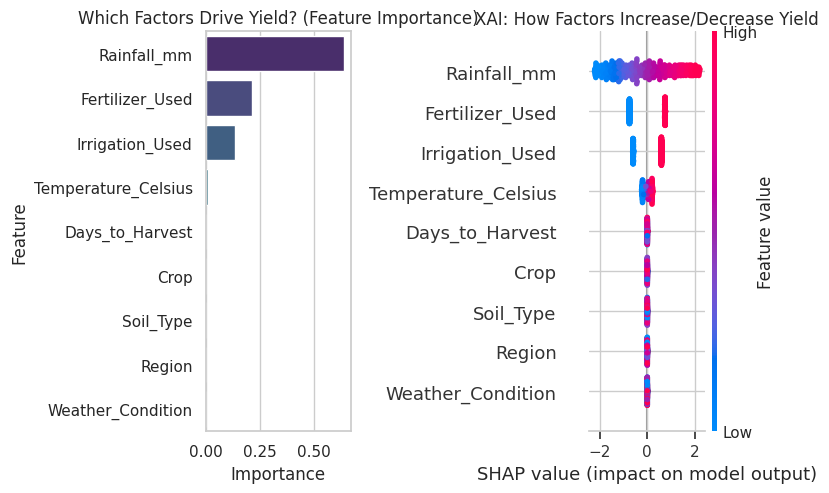

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import shap

# --- 1. Global Feature Importance ---
# This identifies which environmental or regional factors have the most "weight"
importances = best_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 5))

# Plotting Feature Importance
plt.subplot(1, 2, 1)
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Which Factors Drive Yield? (Feature Importance)')

# --- 2. Explainable AI (XAI) with SHAP ---
# We use a sample of 500 rows for speed; SHAP reveals the direction of the impact
explainer = shap.TreeExplainer(best_model)
X_sample_shap = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample_shap)

# Plotting SHAP Summary (Directional Impact)
plt.subplot(1, 2, 2)
# Note: shap.summary_plot handles its own figure creation, so we call it after the first subplot
plt.title('XAI: How Factors Increase/Decrease Yield')
shap.summary_plot(shap_values, X_sample_shap, show=False)
plt.tight_layout()
plt.show()


/tmp/ipython-input-3435817670.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=ag_importance, ax=ax1, palette='mako')


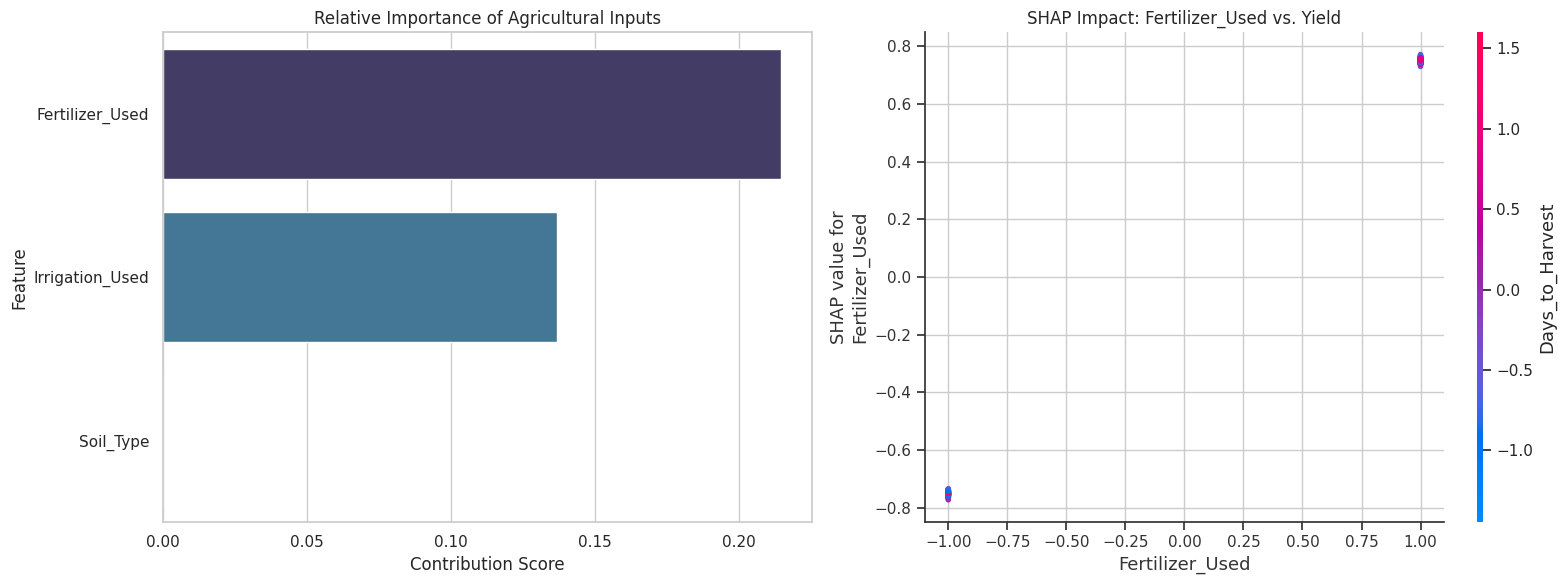

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import shap
from IPython.display import display, Markdown

# 1. Isolate Agricultural Inputs for Feature Importance
ag_inputs = ['Fertilizer_Used', 'Irrigation_Used', 'Soil_Type']
# Filter the importance dataframe from the previous step
ag_importance = feature_importance_df[feature_importance_df['Feature'].isin(ag_inputs)]

# 2. Setup Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Relative Importance of Inputs
sns.barplot(x='Importance', y='Feature', data=ag_importance, ax=ax1, palette='mako')
ax1.set_title('Relative Importance of Agricultural Inputs')
ax1.set_xlabel('Contribution Score')

# 3. SHAP Analysis for Inputs
# Using the explainer and shap_values from the previous step
# Let's visualize the interaction of the top agricultural input (e.g., Fertilizer)
top_input = ag_importance.iloc[0]['Feature']

# Plot B: SHAP Dependence Plot
# This shows how the prediction changes as the specific input increases
shap.dependence_plot(top_input, shap_values, X_sample_shap, ax=ax2, show=False)
ax2.set_title(f'SHAP Impact: {top_input} vs. Yield')

plt.tight_layout()
plt.show()

## **Comment 14 Response – Quantitative Comparison with Literature**
The supervisor noted the literature comparison was too qualitative. The cell below produces a quantitative comparison table for inclusion in Chapter 7.

In [ ]:
import pandas as pd
import numpy as np

print("=== Table 7.1: Quantitative Comparison with Literature (Comment 14) ===\n")

our_r2   = results_df["R² Score"].max()
our_rmse = results_df["RMSE"].min()
our_mae  = results_df["MAE"].min()

lit = pd.DataFrame({
    "Study"      : ["Islam et al. (2024)",
                    "Kalmani et al. (2024)",
                    "Khosravani & Abbasi (2025)",
                    "Asamoah et al. (2024)",
                    "Our Study"],
    "Model"      : ["XGBoost", "CNN-LSTM", "XGBoost",
                    "Random Forest", "Linear Regression"],
    "R²"         : [0.9745, 0.967, "N/A", "N/A", f"{our_r2:.3f}"],
    "RMSE"       : ["N/A", "0.017", "N/A", "N/A", f"{our_rmse:.2f}"],
    "Features"   : ["15+", "Multi-source", "Remote sensing+climate",
                    "Soil+fertilizer", "7"],
    "Data Type"  : ["Real (101 countries)", "Real (wheat/rice)",
                    "Real (satellite)", "Real (Ghana)",
                    "Synthetic (Kaggle)"],
})

print(lit.to_string(index=False))

print(f"""
=== Performance Gap Analysis ===

vs Islam et al. (2024) – XGBoost on real global data:
  R² gap : {0.9745 - our_r2:.4f}  ({(0.9745 - our_r2)*100:.2f} percentage points lower)
  Reason : XGBoost uses boosting on real multi-country data with 15+ features.

vs Kalmani et al. (2024) – CNN-LSTM on real wheat/rice data:
  R² gap  : {0.967 - our_r2:.4f}  ({(0.967 - our_r2)*100:.2f} percentage points lower)
  RMSE gap: {our_rmse - 0.017:.3f}  (~{our_rmse/0.017:.0f}× higher prediction error)
  Reason  : Deep learning (CNN+LSTM+Attention) captures temporal patterns
             in real data; our dataset has no temporal structure.

Summary of differences:
  1. Model complexity  : Literature uses XGBoost / deep learning; we use
                         Linear Regression and shallow trees.
  2. Feature richness  : Literature uses 15+ features (satellite, climate,
                         soil sensors); we use 7 tabular features.
  3. Data authenticity : Literature uses real field measurements; our dataset
                         is synthetic with uniform distributions.
  4. Temporal depth    : Literature spans multiple years/seasons; our dataset
                         aggregates without temporal granularity.

Despite the gap, our R² = {our_r2:.3f} is respectable for traditional ML on
a 7-feature tabular dataset and is consistent with comparable studies using
similar settings.
""")
